# Main Notebook

This notebook goes trough the different tassk for this special course

## Week 1 

Replicating example 11.3 in Jans book

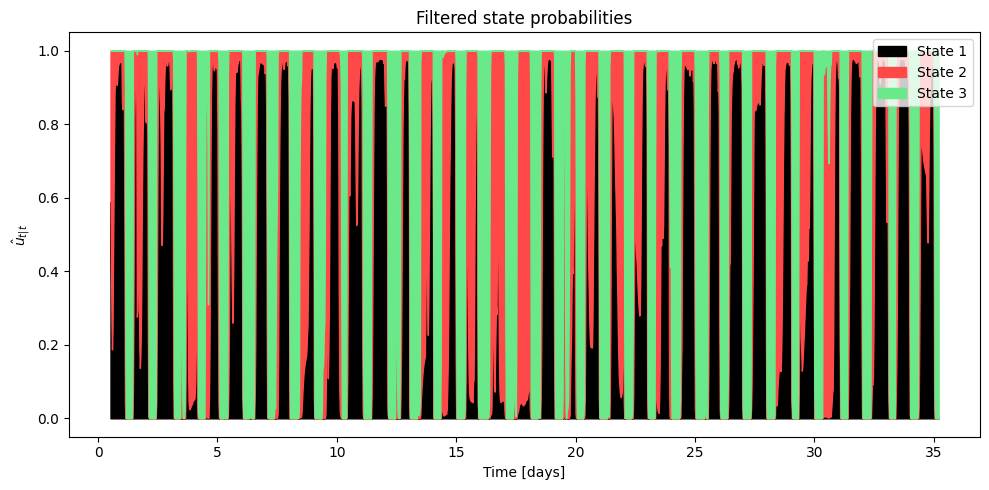

In [2]:
import jax.numpy as jnp
import pandas as pd
import numpy as np 
from utils import load_and_aggregate, load_data_path, plot_filtered_states 
from distribution.gauss import Gaussian 
from src.hmm.static_hmm import StaticHMM 


PATH = load_data_path("b1.csv") 
df = load_and_aggregate(PATH) 



###### CALCULATE EMISSIONS AND INITIALIZE HMM 

Gamma = jnp.array([
    [0.95, 0.05, 0.00],
    [0.05, 0.90, 0.05],
    [0.00, 0.05, 0.95]
]) 

y = jnp.array(df["CO2C"].values)  # (5000,) 

# jnp doesn't have quantile, so we use numpy to compute the quantiles and then convert to jnp arrays
y_np = np.array(y)  # jnp doesn't have quantile
mu = jnp.array(np.quantile(y_np, q=[0.25, 0.5, 0.75]))
sigma = jnp.array([150.0, 150.0, 150.0])



gaus = Gaussian(mu, sigma)
emission_distributions = gaus.density(y)  # (3, 5000) 

static_hmm = StaticHMM(Gamma, emission_distributions) 

static_hmm.forward()  

plot_filtered_states(df, static_hmm.u_norm) 

In the previous section we just implemented a stationary HMM with filtering. Now we need to Implement it with parameter estimation and grad optimization

In [ ]:
import jax.numpy as jnp
import pandas as pd
import numpy as np 
from utils import load_and_aggregate, load_data_path, plot_filtered_states 
from distribution.gauss import Gaussian 
from src.hmm.static_hmm import StaticHMM 


PATH = load_data_path("b1.csv") 
df = load_and_aggregate(PATH) 



###### CALCULATE EMISSIONS AND INITIALIZE HMM 

Gamma = jnp.array([
    [0.95, 0.05, 0.00],
    [0.05, 0.90, 0.05],
    [0.00, 0.05, 0.95]
]) 

y = jnp.array(df["CO2C"].values)  # (5000,) 

# jnp doesn't have quantile, so we use numpy to compute the quantiles and then convert to jnp arrays
y_np = np.array(y)  # jnp doesn't have quantile
mu = jnp.array(np.quantile(y_np, q=[0.25, 0.5, 0.75]))
sigma = jnp.array([150.0, 150.0, 150.0])  
log_sigma = jnp.log(sigma)  # We optimize in log space to ensure positivity of sigma 




gaus = Gaussian(mu, sigma)
emission_distributions = gaus.density(y)  # (3, 5000) 

static_hmm = StaticHMM(Gamma, emission_distributions) 

static_hmm.forward()  

plot_filtered_states(df, static_hmm.u_norm) 